# Model do raportu 3

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [30]:
dane = pd.read_csv('data_rap3.csv')

Podział danych

In [31]:
y = dane.iloc[:, 0].values  # etykiety
X = dane.iloc[:, 1:].values  # piksele

Skalowanie danych

In [32]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Podział na zbiór treningowy i testowy

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 )

Konwersja do tensora PyTorch

In [34]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train - 1, dtype=torch.long)  # klasy: 0 (kostka), 1 (litera)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test - 1, dtype=torch.long)

Klasa modelu

In [35]:
class ProstyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # wyjście: 2 klasy
        )

    def forward(self, x):
        return self.fc(x)

Inicjalizacja modelu

In [36]:
model = ProstyModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []
accuracy_history = []

Trening

In [37]:
epoki = 100
for epoka in range(epoki):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()

    # Ewaluacja
    with torch.no_grad():
        pred = model(X_test_tensor).argmax(dim=1)
        acc = (pred == y_test_tensor).float().mean()
    print(f"Epoka {epoka+1}/{epoki}, Strata: {loss.item():.4f}, Dokładność: {acc:.4f}")

    loss_history.append(loss.item())
    accuracy_history.append(acc.item())

Epoka 1/100, Strata: 0.7073, Dokładność: 0.8574
Epoka 2/100, Strata: 0.5505, Dokładność: 0.9035
Epoka 3/100, Strata: 0.4398, Dokładność: 0.9037
Epoka 4/100, Strata: 0.3552, Dokładność: 0.9042
Epoka 5/100, Strata: 0.2965, Dokładność: 0.9054
Epoka 6/100, Strata: 0.2598, Dokładność: 0.9080
Epoka 7/100, Strata: 0.2382, Dokładność: 0.9111
Epoka 8/100, Strata: 0.2241, Dokładność: 0.9157
Epoka 9/100, Strata: 0.2115, Dokładność: 0.9219
Epoka 10/100, Strata: 0.1970, Dokładność: 0.9288
Epoka 11/100, Strata: 0.1804, Dokładność: 0.9365
Epoka 12/100, Strata: 0.1629, Dokładność: 0.9454
Epoka 13/100, Strata: 0.1466, Dokładność: 0.9537
Epoka 14/100, Strata: 0.1335, Dokładność: 0.9617
Epoka 15/100, Strata: 0.1246, Dokładność: 0.9672
Epoka 16/100, Strata: 0.1199, Dokładność: 0.9701
Epoka 17/100, Strata: 0.1172, Dokładność: 0.9711
Epoka 18/100, Strata: 0.1139, Dokładność: 0.9721
Epoka 19/100, Strata: 0.1081, Dokładność: 0.9733
Epoka 20/100, Strata: 0.0999, Dokładność: 0.9746
Epoka 21/100, Strata: 0.0912,

In [53]:
print(f"\nDokładność: {acc:.4f}")


Dokładność: 0.9998


Wykresy

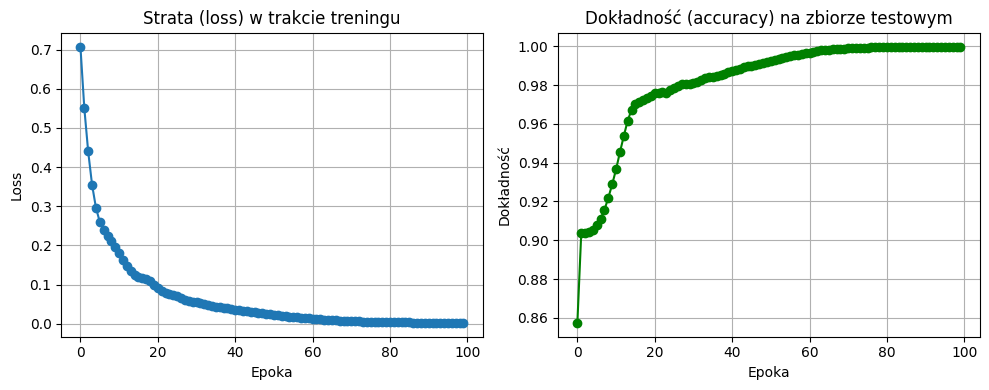

In [40]:
plt.figure(figsize=(10, 4))

# Wykres straty (loss)
plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o')
plt.title("Strata (loss) w trakcie treningu")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.grid(True)

# Wykres dokładności
plt.subplot(1, 2, 2)
plt.plot(accuracy_history, marker='o', color='green')
plt.title("Dokładność (accuracy) na zbiorze testowym")
plt.xlabel("Epoka")
plt.ylabel("Dokładność")
plt.grid(True)

plt.tight_layout()
plt.show()

__________________________________________________________________________________

## A gdyby tak bez modelu?

In [41]:
import pandas as pd
import numpy as np
from collections import Counter
import random

In [42]:
# Funkcja klasyfikująca na podstawie częstości
def classify_image(pixel_values):
    counter = Counter(pixel_values)
    most_common = counter.most_common()

    most_freq_value = most_common[0][0]

    # najczęstsza wartość to 127
    if most_freq_value == 127:
        if len(most_common) > 1:
            most_freq_value = most_common[1][0]

    # najczęstsza wartość to 208
    if most_common[0][0] == 208:
        return 'kostka'

    if 0 <= most_freq_value <= 109:
        return 'litera'
    elif 110 <= most_freq_value <= 150:
        return 'kostka'
    elif 151 <= most_freq_value <= 255:
        return 'litera'
    else:
        return 'nieznane'

In [43]:
def label_to_text(label):
    return 'kostka' if label == 1 else 'litera'

In [44]:
sample_data = dane.sample(n=100000, random_state=42)

In [45]:
correct = 0

In [46]:
for _, row in sample_data.iterrows():
    label = row.iloc[0]  # Etykieta
    pixels = row.iloc[1:].values.astype(int)  # Piksele
    prediction = classify_image(pixels)
    true_label = label_to_text(label)

    if prediction == true_label:
        correct += 1

In [47]:
accuracy = correct / 100000
print(f'Dokładność klasyfikatora: {accuracy*100:.2f}% ({correct}/100000 poprawnych)')

Dokładność klasyfikatora: 72.60% (72596/100000 poprawnych)


### Zawężamy dane

In [48]:
kostka_values = {117, 119, 120, 122, 123, 124, 125, 128, 130, 131, 133, 134, 135, 136}

In [49]:
def classify_image_more(pixel_values):
    counter = Counter(pixel_values)
    most_common = counter.most_common()

    value = most_common[0][0]

    # Specjalny przypadek: 127
    if value == 127 and len(most_common) > 1:
        value = most_common[1][0]

    if value in kostka_values:
        return 'kostka'
    else:
        return 'litera'

In [50]:
correct = 0

In [51]:
for _, row in sample_data.iterrows():
    label = row.iloc[0]  # Etykieta
    pixels = row.iloc[1:].values.astype(int)  # Piksele
    prediction = classify_image_more(pixels)
    true_label = label_to_text(label)

    if prediction == true_label:
        correct += 1

In [52]:
accuracy = correct / 100000
print(f'Dokładność klasyfikatora: {accuracy*100:.2f}% ({correct}/100000 poprawnych)')

Dokładność klasyfikatora: 66.81% (66807/100000 poprawnych)
